In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
import argparse
import soundfile as sf
from IPython.display import Audio
import time
from pathlib import Path 

from transformers import EncodecModel

In [2]:
# Local imports from your project structure
from model.gru_audio_model import RNN, GRUModelConfig
from utils.utils import multi_linspace, steps, plot_condition_tensor

from inference import run_inference

In [3]:
# Point run dir to the folder that Train.ipynb created for its run.

# good one ... run_directory = str(Path('./output/20250811_135640')) # 'Path to the directory of the saved run.'
#run_directory = str(Path('./output/20250828_173834_encodectest_DSWind')) # 'Path to the directory of the saved run.'
#run_directory = str(Path('./output/20250905_130844_encodectest_DSWind_splitseqs')) # 'Path to the directory of the saved run.'
#run_directory = str(Path('./output/20250906_152317_encodectest_DSBugs_splitseqs_sl125_3l_size64_nq4'))
#run_directory = str(Path('./output/20250906_170007_encodectest_DSPistons_splitseqs_sl125_3l_size64_nq4'))
#run_directory = str(Path('./output/20250907_113358_encodectest_TokWotalDuet_splitseqs_sl125_3l_size128_nq8_emb4.5'))
run_directory = str(Path('./output/20250922_132213_nsythtest_unified'))

top_n = 24 #'Sample from the top N most likely outputs.'
temperature = .8 #'Controls the randomness of predictions.'
length_seconds =20.0 #'Length of the audio to generate in seconds.'

frame_rate=75
generation_length = int(length_seconds * frame_rate)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
device

'cpu'

In [4]:
# -------     Load model     -----------#

config_path = os.path.join(run_directory, "config.pt")
checkpoint_path = os.path.join(run_directory, "checkpoints", "last_checkpoint.pt") # "checkpoint_40.pt") # 

assert os.path.exists(run_directory), f"Run directory not found: {run_directory}"
assert os.path.exists(config_path), f"Config file not found: {config_path}"
assert os.path.exists(checkpoint_path), f"Checkpoint file not found: {checkpoint_path}"

saved_configs = torch.load(config_path, weights_only=False)
model_config = saved_configs["model_config"]

clamp_val = saved_configs["data_config"].clamp_val # need this to map between encodec latents and model input ranges


enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz").to(device)
enc_model.eval()

model = RNN(model_config, enc_model).to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model successfully loaded from checkpoint.")
print(f"Using device = {device}")
clamp_val 

Latents embedded in 64 of the GRU input size of 128
Conditioning parameters embedded in 64 of the GRU input size of 128
Model successfully loaded from checkpoint.
Using device = cpu


15

In [5]:

num_cond_params = model_config.cond_size
cond_seq = torch.zeros(generation_length, num_cond_params)

# instID
# cond_seq[:, 0] = torch.FloatTensor(steps(np.array([0,1,0,0,0,0,0,0,0]), generation_length))
# cond_seq[:, 1] = torch.FloatTensor(steps(np.array([0,0,1,0,0,0,0,0,0]), generation_length))
# cond_seq[:, 2] = torch.FloatTensor(steps(np.array([0,0,0,1,0,0,0,0,0]), generation_length))
# cond_seq[:, 3] = torch.FloatTensor(steps(np.array([0,0,0,0,1,0,0,0,0]), generation_length))
# cond_seq[:, 4] = torch.FloatTensor(steps(np.array([0,0,0,0,0,1,0,0,0]), generation_length))
# cond_seq[:, 5] = torch.FloatTensor(steps(np.array([0,0,0,0,0,0,1,0,0]), generation_length))
# cond_seq[:, 6] = torch.FloatTensor(steps(np.array([0,0,0,0,0,0,0,1,0]), generation_length))

# param_1
cond_seq[:, 0] = .5


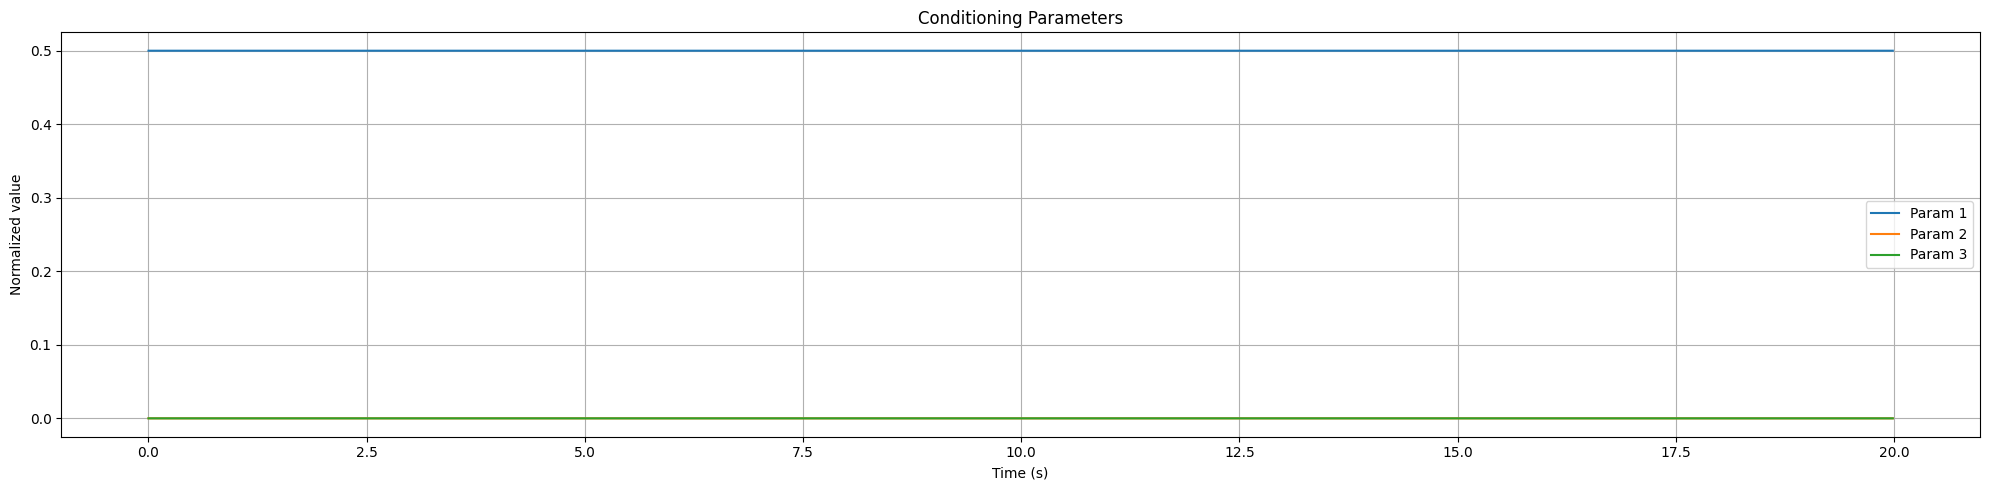

In [6]:
#For nsynth.64.76_sm, the parameter 
#  Param1 - instID
#  Param2 - a (amplitude)
#  Param3 - p (pitch in [0,1], representing midi [64, 76]

plot_condition_tensor(cond_seq, frame_rate)

In [7]:
cond_seq.shape

torch.Size([1500, 3])

In [8]:

warmup_len = 1
sd=.33 # to create data in [-1,1]
warmup_sequence = warmup_tensor = torch.clamp(torch.randn(warmup_len, 128) * sd, -3*sd, 3*sd)    

# want :    x.shape = torch.Size([100, 128]), and c.shape = torch.Size([genseqlen, 1])
print(f'About to call inference with  warmup_sequence.shape = {warmup_sequence.shape}, and cond_seq.shape = {cond_seq.shape}')

start_time = time.monotonic()

generated_audio, sr = run_inference(model, enc_model, cond_seq.to(device), warmup_sequence.to(device), clamp_val, top_n=top_n, temperature=temperature, include_warmup_audio=False)

elapsed_time = time.monotonic() - start_time
print(f"Time to generate: {elapsed_time:.2f}")

About to call inference with  warmup_sequence.shape = torch.Size([1, 128]), and cond_seq.shape = torch.Size([1500, 3])
Starting latent inference... with codebook_size=1024, n_q=4, cond_size=3
Warming up model hidden state with provided latents...
Generating 1500 latent frames...
Latent generation complete. RNN time to generate: 1.24. Converting to audio...
Inference complete - encoding time = 0.61.
Time to generate: 1.86


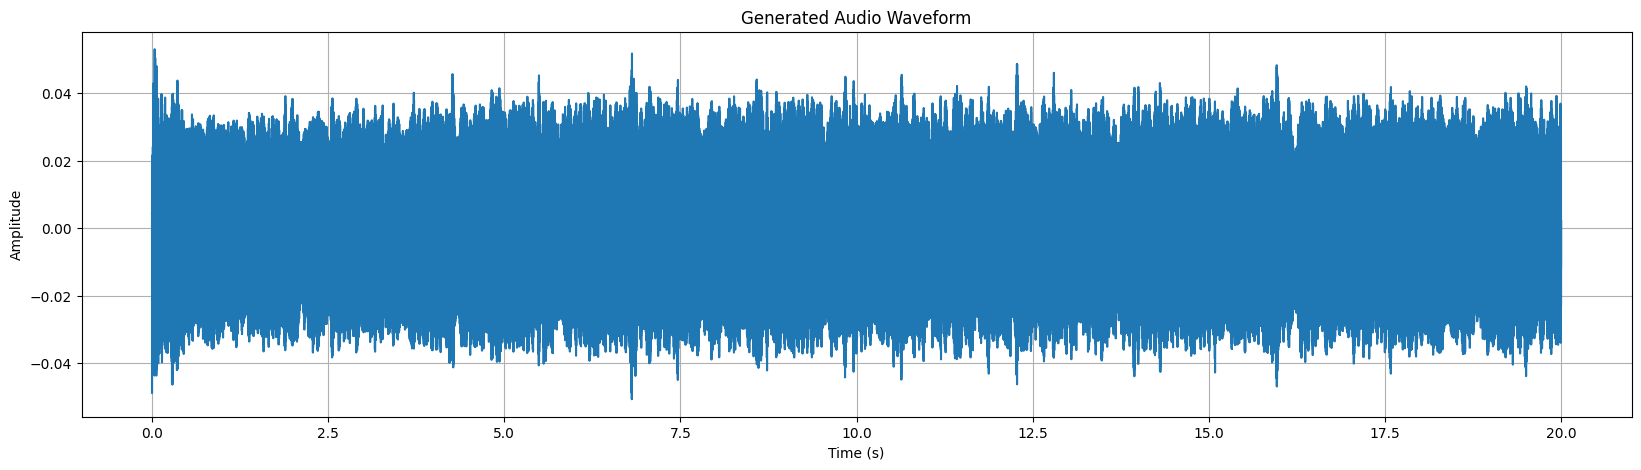

In [9]:
t = np.arange(len(generated_audio)) / sr

#print(f"Saving waveform plot to {args.output_plot_path}")
plt.figure(figsize=(20, 5))
plt.plot(t,generated_audio)
plt.title("Generated Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
#plt.savefig(args.output_plot_path)
#plt.close()

plt.show()

In [10]:
Audio(generated_audio, rate=sr)

In [11]:
#---------------------------------------------------  pitch glide  --------------------#

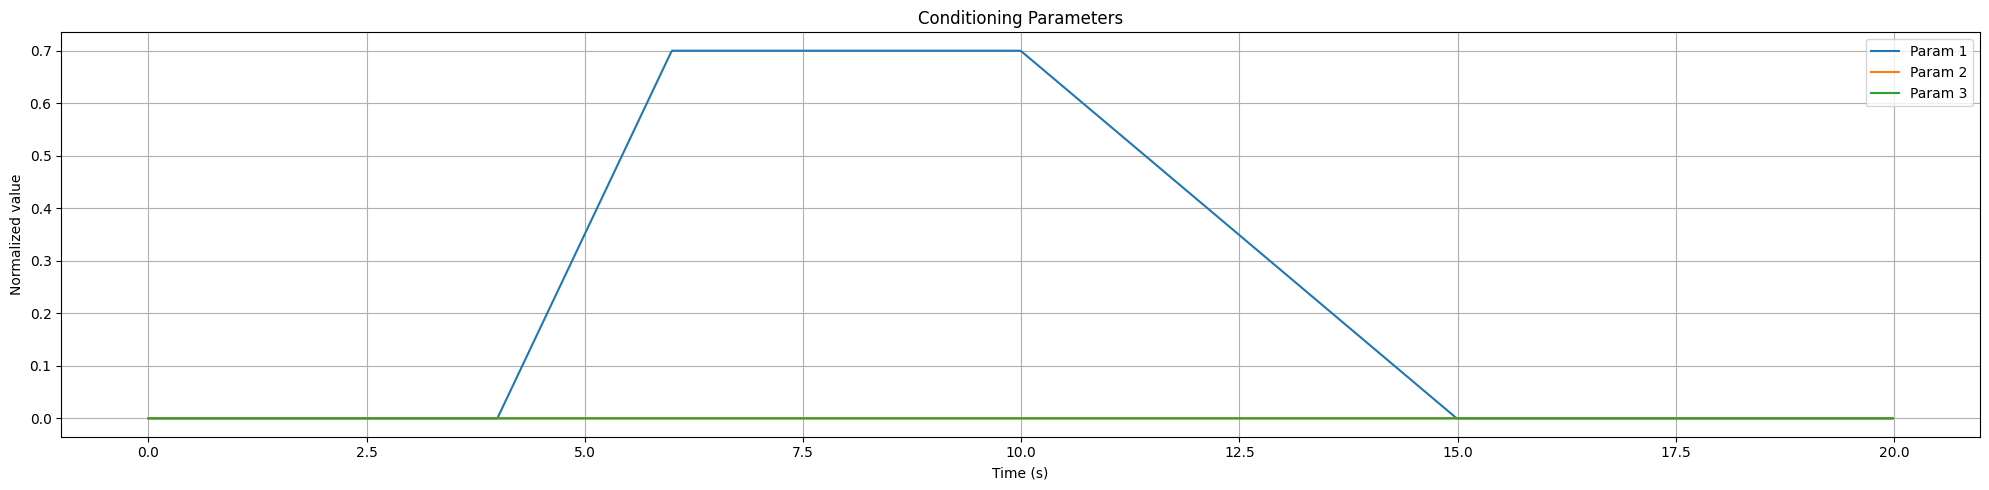

Starting latent inference... with codebook_size=1024, n_q=4, cond_size=3
Warming up model hidden state with provided latents...
Generating 1500 latent frames...
Latent generation complete. RNN time to generate: 1.36. Converting to audio...
Inference complete - encoding time = 0.44.


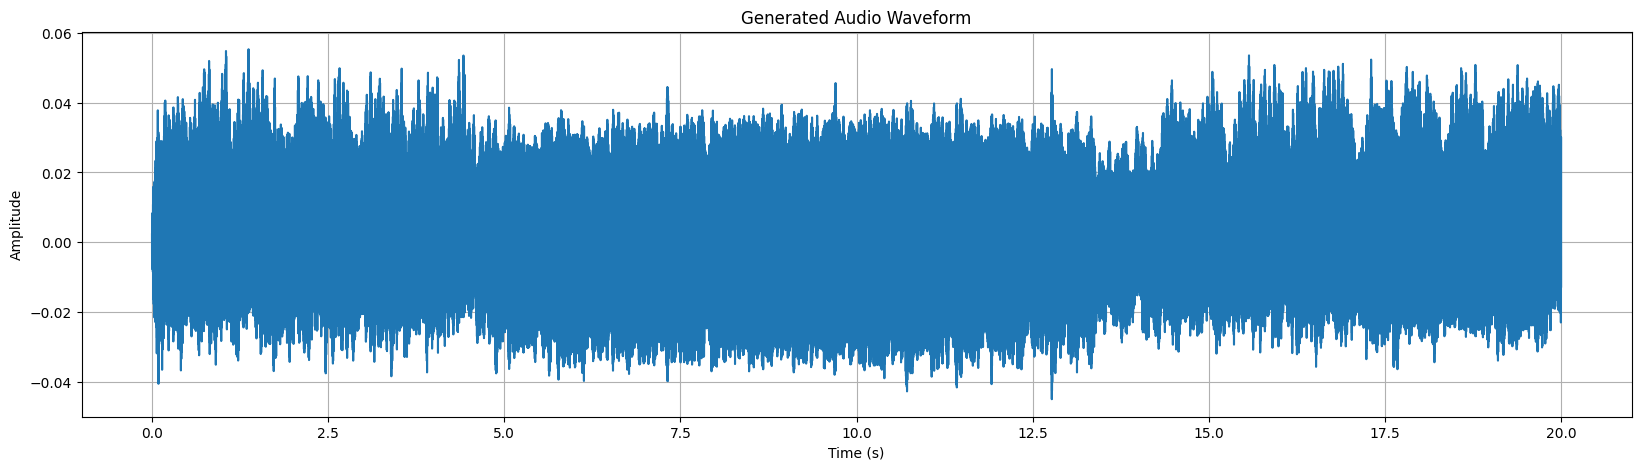

In [12]:
cond_seq = torch.zeros(generation_length, num_cond_params)

num_cond_params = model_config.cond_size
cond_seq = torch.zeros(generation_length, num_cond_params)

# instID
# cond_seq[:, 0] = 0
# cond_seq[:, 1] = 0
# cond_seq[:, 2] = 0   #bugs
# cond_seq[:, 3] = 0
# cond_seq[:, 4] = 0   #pistons
# cond_seq[:, 5] = 0
# cond_seq[:, 6] = 1

# param_1
cond_seq[:, 0] = torch.FloatTensor(multi_linspace([(0, 0),(.2,0), (.3,.7), (.5,.7),(.75,0),(1,0)], generation_length))

plot_condition_tensor(cond_seq, frame_rate)

generated_audio_glide, sr = run_inference(model, enc_model, cond_seq.to(device), warmup_sequence.to(device), clamp_val, top_n=top_n, temperature=temperature, include_warmup_audio=False)

# Create a time axis in seconds
t = np.arange(len(generated_audio_glide)) / sr

plt.figure(figsize=(20, 5))
plt.plot(t, generated_audio_glide)
plt.title("Generated Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()
Audio(generated_audio_glide, rate=sr)